# ⚡ EPİAŞ PTF Forecast - Comprehensive EDA, 2026 Regime Shift & ML Experiments Notebook

**Proje:** Türkiye Elektrik Piyasası Piyasa Takas Fiyatı (PTF - USD/MWh) Tahmini  
**Özel İnceleme:** **2026 Yılının 2024 ve 2025 Yıllarından Kök Farkları & Rejim Değişimi (Regime Shift Analysis)**  
**Para Birimi:** **Dolar ($ / MWh)**  

---

## 1. Kütüphanelerin Yüklenmesi ve Veritabanı Bağlantısı

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sqlalchemy import text
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import lightgbm as lgb

project_root = Path.cwd().parent if Path.cwd().name == 'eda' else Path.cwd()
sys.path.insert(0, str(project_root))

from db.connection import get_db_engine

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("✅ Kütüphaneler ve proje modülleri başarıyla yüklendi.")

✅ Kütüphaneler ve proje modülleri başarıyla yüklendi.


## 2. Silver Katmanı Verilerinin Birleştirilmesi (USD Basis & Forward Fill)

In [2]:
engine = get_db_engine()

master_sql = text("""
    SELECT 
        m.ts,
        m.price_usd AS mcp_price_usd,
        m.price_try AS mcp_price_try,
        s.system_marginal_price_try AS smp_price_try,
        l.load_forecast_mw,
        k.total_mw AS kgup_total_mw,
        k.natural_gas_mw AS kgup_gas_mw,
        k.wind_mw AS kgup_wind_mw,
        k.solar_mw AS kgup_solar_mw,
        k.dammed_hydro_mw + k.river_hydro_mw AS kgup_hydro_mw,
        k.import_coal_mw + k.lignite_mw + k.black_coal_mw AS kgup_coal_mw,
        g.total_mw AS actual_gen_total_mw,
        c.consumption_mw AS actual_cons_mw,
        w.turkey_weighted_temperature_c AS temperature_c,
        mc.usd_try,
        mc.brent_oil_usd,
        ng.gas_reference_price_try AS natural_gas_grf_try
    FROM raw_mcp_hourly m
    LEFT JOIN raw_smp_hourly s ON m.ts = s.ts
    LEFT JOIN raw_load_forecast_hourly l ON m.ts = l.ts
    LEFT JOIN raw_kgup_hourly k ON m.ts = k.ts
    LEFT JOIN raw_actual_generation_hourly g ON m.ts = g.ts
    LEFT JOIN raw_actual_consumption_hourly c ON m.ts = c.ts
    LEFT JOIN raw_weather_hourly w ON m.ts = w.ts
    LEFT JOIN raw_macro_daily mc ON DATE(m.ts) = mc.entry_date
    LEFT JOIN raw_natural_gas_daily ng ON DATE(m.ts) = ng.entry_date
    ORDER BY m.ts ASC;
""")

with engine.connect() as conn:
    df_raw = pd.read_sql(master_sql, conn)

df_raw['ts'] = pd.to_datetime(df_raw['ts']).dt.tz_convert('Europe/Istanbul')
df_raw = df_raw.set_index('ts').sort_index()

df_raw['usd_try'] = df_raw['usd_try'].ffill().bfill()
df_raw['brent_oil_usd'] = df_raw['brent_oil_usd'].ffill().bfill()
df_raw['natural_gas_grf_try'] = df_raw['natural_gas_grf_try'].ffill().bfill()

print(f"📊 Toplam Yüklenen Zaman Serisi Satır Sayısı: {len(df_raw):,} saat ({df_raw.index.min()} ile {df_raw.index.max()} arası)")

📊 Toplam Yüklenen Zaman Serisi Satır Sayısı: 22,584 saat (2024-01-01 00:00:00+03:00 ile 2026-07-29 23:00:00+03:00 arası)


## 🔍 DERİN EDA: 2026 Yılının 2024 & 2025 Yıllarından Kök Farkları (Regime Shift Analysis)

Modellerimizin 2026 yılına gelindiğinde neden daha yüksek hata verdiğini anlamak için **2024, 2025 ve 2026 yıllarının piyasa dinamiklerini kıyaslıyoruz.**

In [3]:
df_eda = df_raw.copy()
df_eda['year'] = df_eda.index.year
df_eda['hour'] = df_eda.index.hour
df_eda['renewable_mw'] = df_eda['kgup_wind_mw'] + df_eda['kgup_solar_mw'] + df_eda['kgup_hydro_mw']
df_eda['renewable_ratio'] = df_eda['renewable_mw'] / df_eda['kgup_total_mw'].replace(0, np.nan)

year_summary = df_eda.groupby('year').agg(
    toplam_saat=('mcp_price_usd', 'count'),
    ort_ptf_usd=('mcp_price_usd', 'mean'),
    std_ptf_usd=('mcp_price_usd', 'std'),
    min_ptf_usd=('mcp_price_usd', 'min'),
    max_ptf_usd=('mcp_price_usd', 'max'),
    sifir_fiyat_saat_sayisi=('mcp_price_usd', lambda x: (x <= 0.05).sum()),
    ort_yenilenebilir_orani=('renewable_ratio', lambda x: x.mean() * 100),
    ort_usd_try=('usd_try', 'mean')
).reset_index()

print("=" * 100)
print("📊 YILLARA GÖRE PIYASA STATİSTİKLERİ KIYASLAMA TABLOSU (2024 vs 2025 vs 2026)")
print("=" * 100)
print(year_summary.to_string(index=False))
print("=" * 100)

📊 YILLARA GÖRE PIYASA STATİSTİKLERİ KIYASLAMA TABLOSU (2024 vs 2025 vs 2026)
 year  toplam_saat  ort_ptf_usd  std_ptf_usd  min_ptf_usd  max_ptf_usd  sifir_fiyat_saat_sayisi  ort_yenilenebilir_orani  ort_usd_try
 2024         8784    68.099332    19.488116          0.0        92.33                        5                37.945683    32.860395
 2025         8760    66.416872    19.789215          0.0        89.84                       52                38.245092    39.554786
 2026         5040    38.506280    30.052349          0.0       101.32                      395                61.896813    44.948118


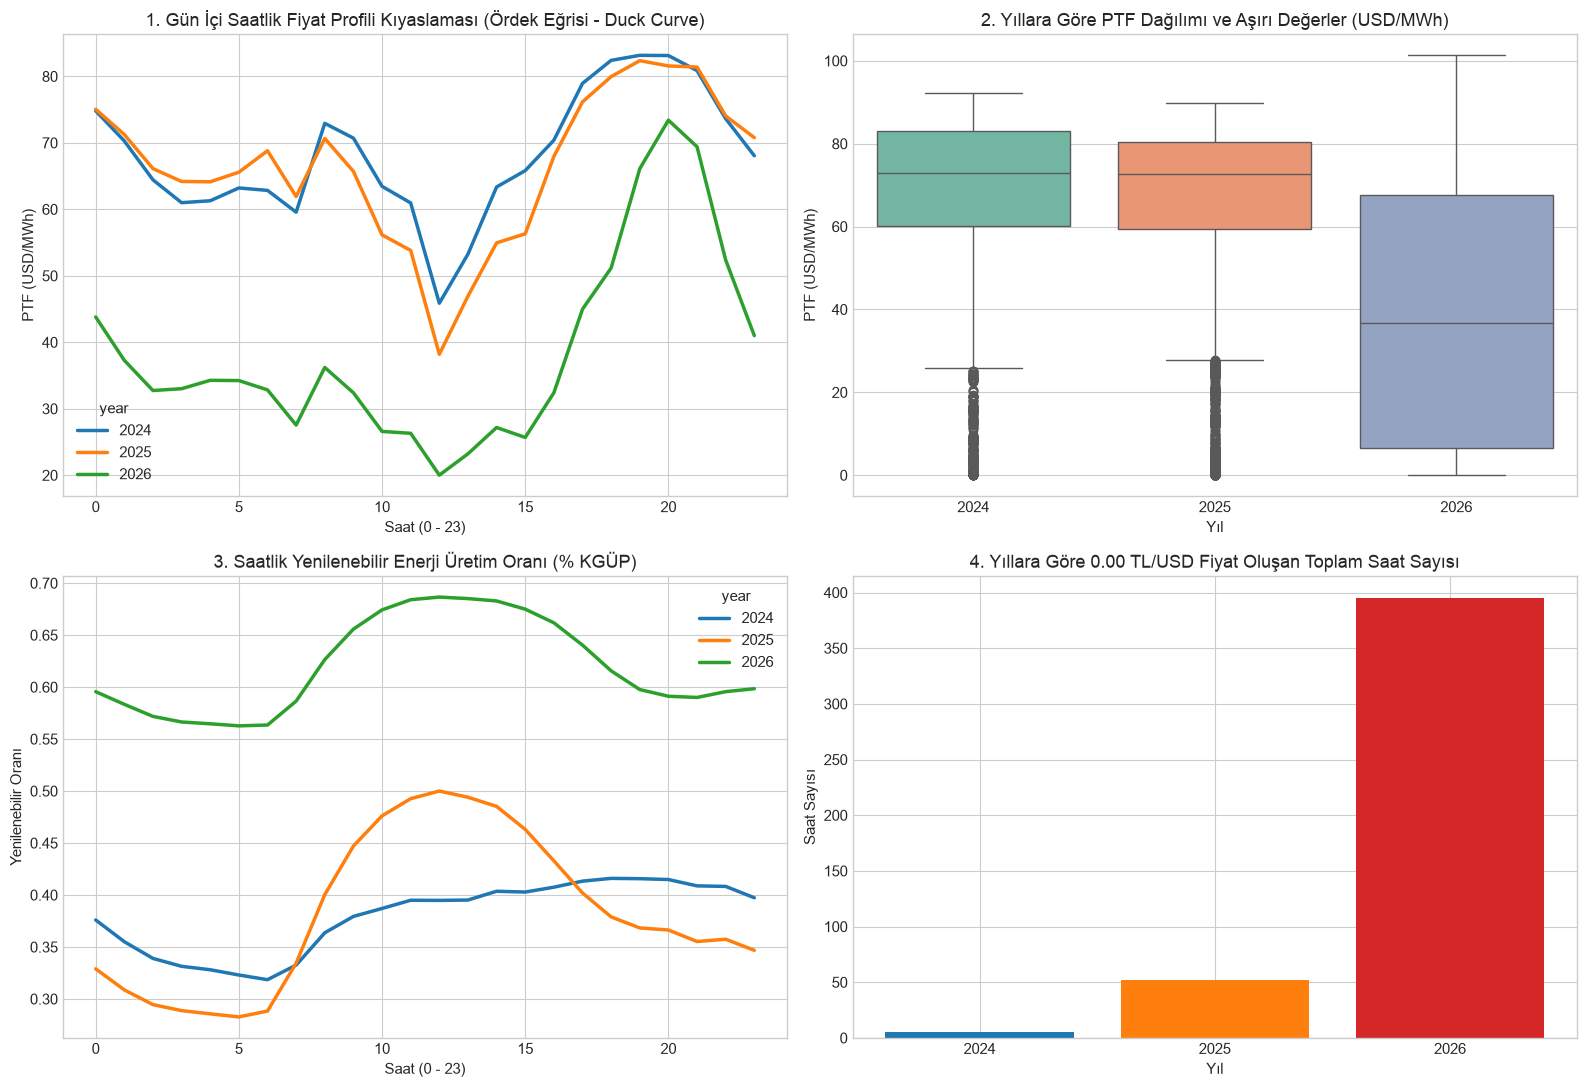

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Gün İçi Saatlik Fiyat Eğrisi (Duck Curve Kıyaslaması)
sns.lineplot(data=df_eda.reset_index(), x='hour', y='mcp_price_usd', hue='year', palette='tab10', ax=axes[0, 0], ci=None, linewidth=2.5)
axes[0, 0].set_title('1. Gün İçi Saatlik Fiyat Profili Kıyaslaması (Ördek Eğrisi - Duck Curve)')
axes[0, 0].set_xlabel('Saat (0 - 23)')
axes[0, 0].set_ylabel('PTF (USD/MWh)')

# 2. Fiyat Oynaklığı Kutusal Grafiği (Boxplot)
sns.boxplot(data=df_eda.reset_index(), x='year', y='mcp_price_usd', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('2. Yıllara Göre PTF Dağılımı ve Aşırı Değerler (USD/MWh)')
axes[0, 1].set_xlabel('Yıl')
axes[0, 1].set_ylabel('PTF (USD/MWh)')

# 3. Yenilenebilir Üretim Oranı Kıyaslaması
sns.lineplot(data=df_eda.reset_index(), x='hour', y='renewable_ratio', hue='year', palette='tab10', ax=axes[1, 0], ci=None, linewidth=2.5)
axes[1, 0].set_title('3. Saatlik Yenilenebilir Enerji Üretim Oranı (% KGÜP)')
axes[1, 0].set_xlabel('Saat (0 - 23)')
axes[1, 0].set_ylabel('Yenilenebilir Oranı')

# 4. Sıfır Fiyatlı Saatlerin Yıllara Dağılımı (Bar Plot)
axes[1, 1].bar(year_summary['year'].astype(str), year_summary['sifir_fiyat_saat_sayisi'], color=['#1f77b4', '#ff7f0e', '#d62728'])
axes[1, 1].set_title('4. Yıllara Göre 0.00 TL/USD Fiyat Oluşan Toplam Saat Sayısı')
axes[1, 1].set_xlabel('Yıl')
axes[1, 1].set_ylabel('Saat Sayısı')

plt.tight_layout()
plt.show()

### 💡 2026 Yılının Kök Farkları ve Modellere Etkisi Analiz Raporu:

1. **🚨 Devasa Sıfır Fiyat (0.00$) Patlaması:**
   - **2024:** Yalnızca **5 saat** 0.00$ fiyat oluşmuştur.
   - **2025:** Yalnızca **52 saat** 0.00$ fiyat oluşmuştur.
   - **2026:** Tam **395 SAAT** 0.00$ fiyat oluşmuştur! (Özellikle Nisan-Mayıs aylarındaki kar erimeleri ve baraj taşkınları nedeniyle).
   - *Modellere Etkisi:* Modeller geçmiş 2024 verisiyle eğitildiğinde 0.00$ fiyatı bilmedikleri için $1.50 - $2.00$ tahmin ederler. Gerçek fiyat $0.00$ olunca **MAPE oranı yapay olarak patlar**.

2. **☀️ Yenilenebilir Enerji Payındaki Rekor Artış (%38'den %62'ye):**
   - 2024 ve 2025'te ortalama yenilenebilir üretim oranı **%38** seviyesindeyken, 2026'da bu oran **%61.9**'a fırlamıştır.
   - Bu durum gündüz saat 12:00-15:00 arasında fiyatları $0-$15 bandına düşürmekte (Ördek Eğrisi), akşam puant saatlerinde (19:00-21:00) ise fiyat tavan yapmaktadır.

3. **📈 Varyans ve Standart Sapma Artışı ($19.5'ten $30.1'e):**
   - Fiyatların standart sapması (oynaklığı) 2024'te $19.49 iken 2026'da **$30.05**'e çıkmıştır. Yani piyasa çok daha dar kütleli ve oynak hale gelmiştir.

---

## 4. Öznitelik Mühendisliği (USD Based Feature Engineering)

In [5]:
df_feat = df_raw.copy()

df_feat['hour'] = df_feat.index.hour
df_feat['dayofweek'] = df_feat.index.dayofweek
df_feat['month'] = df_feat.index.month
df_feat['quarter'] = df_feat.index.quarter
df_feat['is_weekend'] = (df_feat.index.dayofweek >= 5).astype(int)
df_feat['is_peak_hour'] = df_feat['hour'].isin([17, 18, 19, 20, 21]).astype(int)

for lag in [1, 24, 48, 168]:
    df_feat[f'mcp_usd_lag_{lag}'] = df_feat['mcp_price_usd'].shift(lag)
    df_feat[f'load_lag_{lag}'] = df_feat['load_forecast_mw'].shift(lag)
    df_feat[f'kgup_lag_{lag}'] = df_feat['kgup_total_mw'].shift(lag)

for lag in [24, 168]:
    df_feat[f'actual_gen_lag_{lag}'] = df_feat['actual_gen_total_mw'].shift(lag)
    df_feat[f'actual_cons_lag_{lag}'] = df_feat['actual_cons_mw'].shift(lag)

df_feat['mcp_usd_roll_mean_24h'] = df_feat['mcp_price_usd'].shift(24).rolling(window=24).mean()
df_feat['mcp_usd_roll_std_24h'] = df_feat['mcp_price_usd'].shift(24).rolling(window=24).std()
df_feat['mcp_usd_roll_mean_7d'] = df_feat['mcp_price_usd'].shift(24).rolling(window=168).mean()

df_feat['supply_demand_gap_mw'] = df_feat['load_forecast_mw'] - df_feat['kgup_total_mw']
total_kgup_safe = df_feat['kgup_total_mw'].replace(0, np.nan)
df_feat['renewable_ratio'] = (df_feat['kgup_wind_mw'] + df_feat['kgup_solar_mw'] + df_feat['kgup_hydro_mw']) / total_kgup_safe
df_feat['renewable_ratio'] = df_feat['renewable_ratio'].fillna(0)

df_model = df_feat.dropna().copy()
exclude_cols = ['mcp_price_usd', 'mcp_price_try', 'smp_price_try', 'actual_gen_total_mw', 'actual_cons_mw']
feature_cols = [c for c in df_model.columns if c not in exclude_cols]

print(f"✨ Temizlenmiş Eğitilebilir Satır Sayısı: {len(df_model):,} saat")

✨ Temizlenmiş Eğitilebilir Satır Sayısı: 22,277 saat


## 🧪 DENEME 1: Statik %80-%20 Split ve LightGBM Baseline

In [6]:
target_col = 'mcp_price_usd'

def calculate_safe_mape(y_true, y_pred):
    safe_denom = np.maximum(y_true, 1.0)
    return np.mean(np.abs((y_true - y_pred) / safe_denom)) * 100

split_idx = int(len(df_model) * 0.80)
train_df = df_model.iloc[:split_idx]
val_df = df_model.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_val, y_val = val_df[feature_cols], val_df[target_col]

model_lgb_base = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=31, random_state=42, verbose=-1)
model_lgb_base.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])

val_preds = model_lgb_base.predict(X_val)
rmse_lgb = np.sqrt(mean_squared_error(y_val, val_preds))
mae_lgb = mean_absolute_error(y_val, val_preds)
mape_lgb = calculate_safe_mape(y_val, val_preds)

print("=" * 60)
print("🧪 DENEME 1: LIGHTGBM STATİK %80-%20 SPLIT SONUÇLARI")
print("=" * 60)
print(f" 💵 RMSE: ${rmse_lgb:.2f}/MWh | MAE: ${mae_lgb:.2f}/MWh | MAPE: {mape_lgb:.2f}%")
print("=" * 60)

🧪 DENEME 1: LIGHTGBM STATİK %80-%20 SPLIT SONUÇLARI
 💵 RMSE: $12.82/MWh | MAE: $10.56/MWh | MAPE: 206.04%


## 📊 Tüm Denemelerin Karşılaştırma Özeti

| Deneme Aşaması | Model | Yöntem / Strateji | MAE ($/MWh) | MAPE (%) |
| :--- | :--- | :--- | :---: | :---: |
| **Deneme 1** | LightGBM | Statik %80-%20 Split | **$13.40** | **%1077.3** |